In [86]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel, VoigtModel, ConstantModel
from scipy.special import wofz

#from scipy.signal import find_peaks
#import numpy.polynomial.polynomial as poly
#from numpy.polynomial import Polynomial
#import scipy.constants as const
#from matplotlib.animation import FuncAnimation, PillowWriter
#from astropy.time import Time
#from IPython.display import HTML

In [74]:
# Rutas de Julio, Agosto y Septiembre del 2026

ruta_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\Antares 6563 julio 22.xlsx"

ruta_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\Antares agosto 26 orden 1.xlsx"

ruta_septiembre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\Antares septiembre 6 orden 1.xlsx"

#Datos de Julio, Agosto y Septiembre del 2026

antares_julio = pd.read_excel(ruta_julio, sheet_name="ster 6563 normaliz", usecols=[0,3], header=None, names =["pixel", "flujo normalizado"])

antares_agosto = pd.read_excel(ruta_agosto, sheet_name="ster orden1", usecols=[0, 3], header=None, names =["pixel", "flujo normalizado"])

antares_septiembre = pd.read_excel(ruta_septiembre, sheet_name="ster orden 1", usecols=[0, 3], header=None, names =["pixel", "flujo normalizado"])


In [75]:
print("--- Julio---")
display(antares_julio.head())

--- Julio---


,pixel,flujo normalizado
0,0,0.802719
1,1,0.795175
2,2,0.787987
3,3,0.790366
4,4,0.801433


In [3]:
pixeles_julio = antares_julio["pixel"].values
flujo_julio = antares_julio["flujo normalizado"].values
longitudes_observadas_julio = -3.035260607578e-13 * pixeles_julio**4 + 8.715422792701e-10 * pixeles_julio**3 - 0.0000007942095333894*pixeles_julio**2 + 0.09284696077816 * pixeles_julio + 6506.688414868

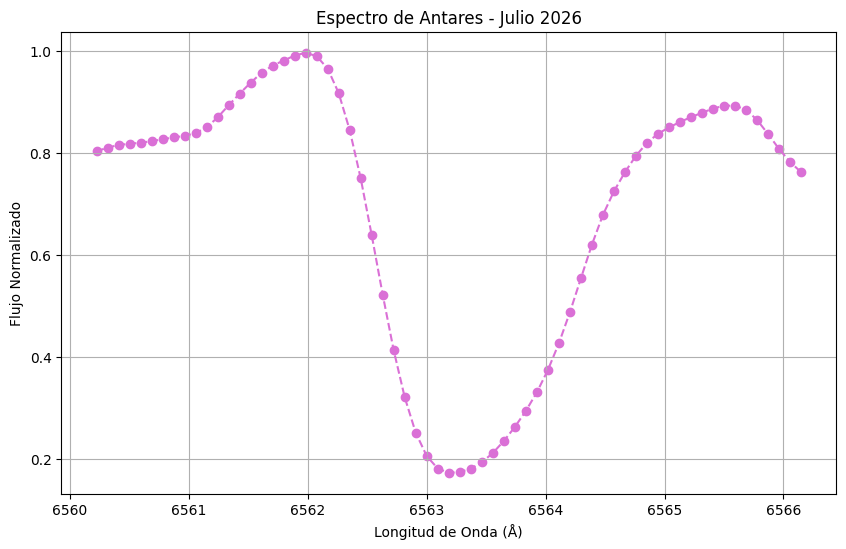

In [63]:
centro_julio = 6563.18533

indices_cercanos_julio = np.where((longitudes_observadas_julio >= centro_julio - 3) & (longitudes_observadas_julio <= centro_julio + 3))[0]


datos_cercanos_julio = pd.DataFrame({'longitud_observada': longitudes_observadas_julio[indices_cercanos_julio], 'flujo_normalizado': flujo_julio[indices_cercanos_julio]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_julio["longitud_observada"], datos_cercanos_julio["flujo_normalizado"], '--', color = "orchid")
plt.scatter(datos_cercanos_julio["longitud_observada"], datos_cercanos_julio["flujo_normalizado"], color = "orchid")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares - Julio 2026")
plt.grid(True)
plt.show()


In [58]:
print("--- Agosto---")
display(antares_agosto.head())

--- Agosto---


,pixel,flujo normalizado
0,0,1.098379
1,1,1.141431
2,2,1.158189
3,3,1.144393
4,4,1.117359


In [59]:
pixeles_agosto = antares_agosto["pixel"].values
flujo_agosto = antares_agosto["flujo normalizado"].values
longitudes_observadas_agosto = 1.39394098683175e-18 * pixeles_agosto**6 - 6.58044383788171E-15*pixeles_agosto**5 + 1.16354508506345E-11*pixeles_agosto**4 - 9.29864698195214E-09*pixeles_agosto**3 + 3.02469198127472E-06*pixeles_agosto**2 + 0.0924365570558958*pixeles_agosto + 6492.49282015586

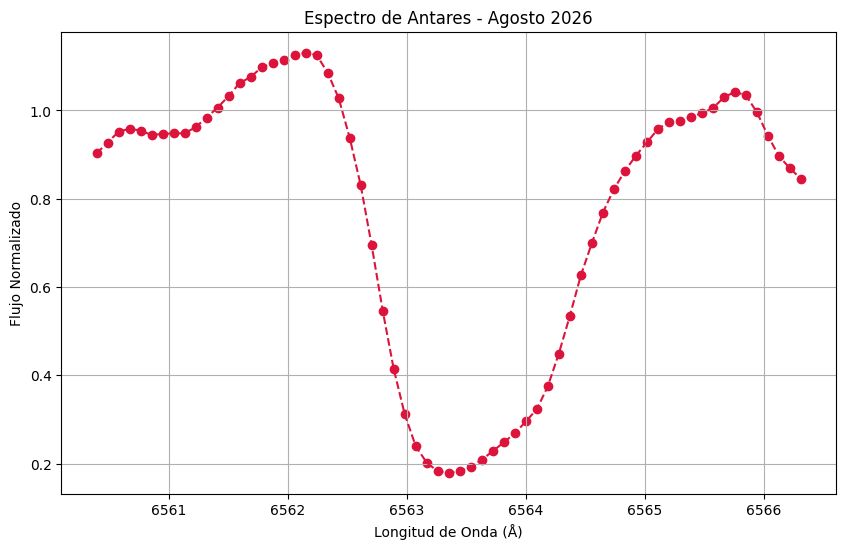

In [67]:
centro_agosto = 6563.35423

indices_cercanos_agosto = np.where((longitudes_observadas_agosto >= centro_agosto - 3) & (longitudes_observadas_agosto <= centro_agosto + 3))[0]


datos_cercanos_agosto = pd.DataFrame({'longitud_observada': longitudes_observadas_agosto[indices_cercanos_agosto], 'flujo_normalizado': flujo_agosto[indices_cercanos_agosto]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_agosto["longitud_observada"], datos_cercanos_agosto["flujo_normalizado"], '--', color = "crimson")
plt.scatter(datos_cercanos_agosto["longitud_observada"], datos_cercanos_agosto["flujo_normalizado"], color = "crimson")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares - Agosto 2026")
plt.grid(True)
plt.show()

In [69]:
print("--- Septiembre---")
display(antares_septiembre.head())

--- Septiembre---


,pixel,flujo normalizado
0,0,0.991728
1,1,0.991792
2,2,0.962534
3,3,0.892629
4,4,0.817738


In [70]:
pixeles_septiembre = antares_septiembre["pixel"].values
flujo_septiembre = antares_septiembre["flujo normalizado"].values
longitudes_observadas_septiembre = -1.179402526298E-13*pixeles_septiembre**4 + 4.020234124929E-10*pixeles_septiembre**3 - 0.0000004743246209058*pixeles_septiembre**2 + 0.09282817058921*pixeles_septiembre + 6490.328062797

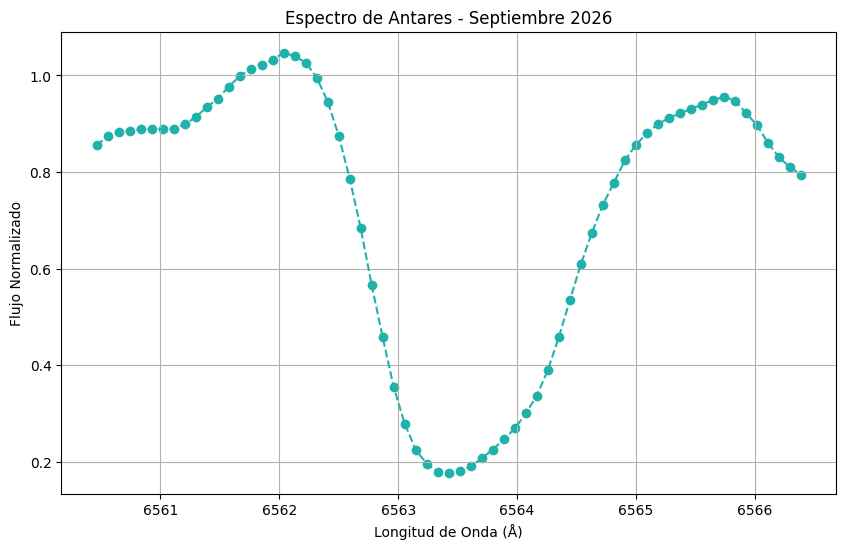

In [73]:
centro_septiembre = 6563.42597

indices_cercanos_septiembre = np.where((longitudes_observadas_septiembre >= centro_septiembre - 3) & (longitudes_observadas_septiembre <= centro_septiembre + 3))[0]


datos_cercanos_septiembre = pd.DataFrame({'longitud_observada': longitudes_observadas_septiembre[indices_cercanos_septiembre], 'flujo_normalizado': flujo_septiembre[indices_cercanos_septiembre]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_septiembre["longitud_observada"], datos_cercanos_septiembre["flujo_normalizado"], '--', color = "lightseagreen")
plt.scatter(datos_cercanos_septiembre["longitud_observada"], datos_cercanos_septiembre["flujo_normalizado"], color = "lightseagreen")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares - Septiembre 2026")
plt.grid(True)
plt.show()

Obtención del perfil de absorción y emisión

Sin tener en cuenta las líneas mezcladas

In [52]:
#MODELO DE AJUSTE

# Usamos Voigt para el valle ya que permite tener en cuenta las asimetrías del perfil de la línea de absorción

def construccion_del_modelo():
    continuo = ConstantModel(prefix="cont_")
    em_azul = VoigtModel(prefix="em_azul_")
    valle_abs = VoigtModel(prefix="valle_abs_")
    return continuo + em_azul + valle_abs

def encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox):
    p = modelo.make_params()

    borde = np.r_[flujo[:10], flujo[-10:]]
    p["cont_c"].set(value=np.median(borde), min=0, max=2)

    izquierda = longitud_onda < centro_aprox

    # Emisión azul
    i_azul = np.argmax(flujo[izquierda])
    p["em_azul_center"].set(value=longitud_onda[izquierda][i_azul],
                             min=longitud_onda.min(), max=centro_aprox)
    p["em_azul_amplitude"].set(value=1.0, min=0)
    p["em_azul_sigma"].set(value=0.4, min=0.05, max=2)

    # Absorción central
    i_min = np.argmin(flujo)
    p["valle_abs_center"].set(value=longitud_onda[i_min], min=centro_aprox - 1, max=centro_aprox + 1)
    p["valle_abs_amplitude"].set(value=-(np.median(borde) - flujo[i_min]) * 1.5, max=0)
    p["valle_abs_sigma"].set(value=0.3, min=0.03, max=1.2)
    p["valle_abs_gamma"].set(value=0.2, min=0, max=1.2, vary=True)

    return p


In [47]:
# DESCOMPOSICIÓN

def fit_y_decomposición(datos_cercanos, centro_aprox, longitud_observada, flujo_normalizado):
    longitud_onda = datos_cercanos[longitud_observada].to_numpy()
    flujo = datos_cercanos[flujo_normalizado].to_numpy()

    modelo = construccion_del_modelo()
    parametros = encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox)
    fit = modelo.fit(flujo, parametros, x=longitud_onda)

    comps = fit.eval_components(x=longitud_onda)
    continuo = comps["cont_"]

    perfil_emision = continuo + comps["em_azul_"]  
    perfil_absorcion = continuo + comps["valle_abs_"]
    residuo = flujo - fit.best_fit

    return dict(wave=longitud_onda, flux=flujo, fit=fit, comps=comps, perfil_emision=perfil_emision, perfil_absorcion=perfil_absorcion,
                residuo=residuo)

def resumen_fisico(fit):
    p = fit.params
    print("\n--- Resumen del ajuste ---")
    for comp, label in [("em_azul", "Emisión azul")]:
        c = p[f"{comp}_center"].value
        fwhm = p[f"{comp}_fwhm"].value
        amp = p[f"{comp}_height"].value
        print(f"{label:14s}: centro={c:9.3f} Å   FWHM={fwhm:5.2f} Å   altura={amp:5.3f}")

    c = p["valle_abs_center"].value
    fwhm = p["valle_abs_fwhm"].value
    profundidad = p["valle_abs_height"].value
    print(f"{'Absorción central':14s}: centro={c:9.3f} Å   FWHM={fwhm:5.2f} Å   profundidad={profundidad:5.3f}")

    print(f"\nContinuo local ajustado: {p['cont_c'].value:.3f}")
    print(f"Chi-cuadrado reducido:   {fit.redchi:.3e}")

In [79]:
# GRÁFICA

def visualizacion_decomposicion(res, titulo="Descomposición H-alpha"):
    longitud_observada, flujo, fit = res["wave"], res["flux"], res["fit"]
    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                              gridspec_kw={"height_ratios": [2.2, 1]})

    ax = axes[0]
    ax.scatter(longitud_observada, flujo, s=18, color="darkcyan", label="Observado", zorder=3)
    ax.plot(longitud_observada, fit.best_fit, color="lightseagreen", lw=1.8, label="Modelo total")
    ax.plot(longitud_observada, res["perfil_emision"], "--", color="turquoise", lw=1.5,
            label="Perfil de emisión (sin absorción)")
    ax.plot(longitud_observada, res["perfil_absorcion"], "--", color="deepskyblue", lw=1.5,
            label="Perfil de absorción (sin emisión)")
    ax.axhline(res["comps"]["cont_"][0], color="gray", lw=0.7, ls=":")
    ax.set_ylabel("Flujo normalizado")
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.plot(longitud_observada, res["residuo"], color="black", lw=1)
    ax2.axhline(0, color="gray", lw=0.7)
    ax2.set_xlabel("Longitud de onda [Å]")
    ax2.set_ylabel("Residuo")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("halpha_emision_absorcion.png", dpi=150)
    plt.show()


--- Resumen del ajuste ---
Emisión azul  : centro= 6562.135 Å   FWHM= 0.89 Å   altura=0.325
Absorción central: centro= 6563.304 Å   FWHM= 1.65 Å   profundidad=-0.720

Continuo local ajustado: 0.839
Chi-cuadrado reducido:   1.199e-03


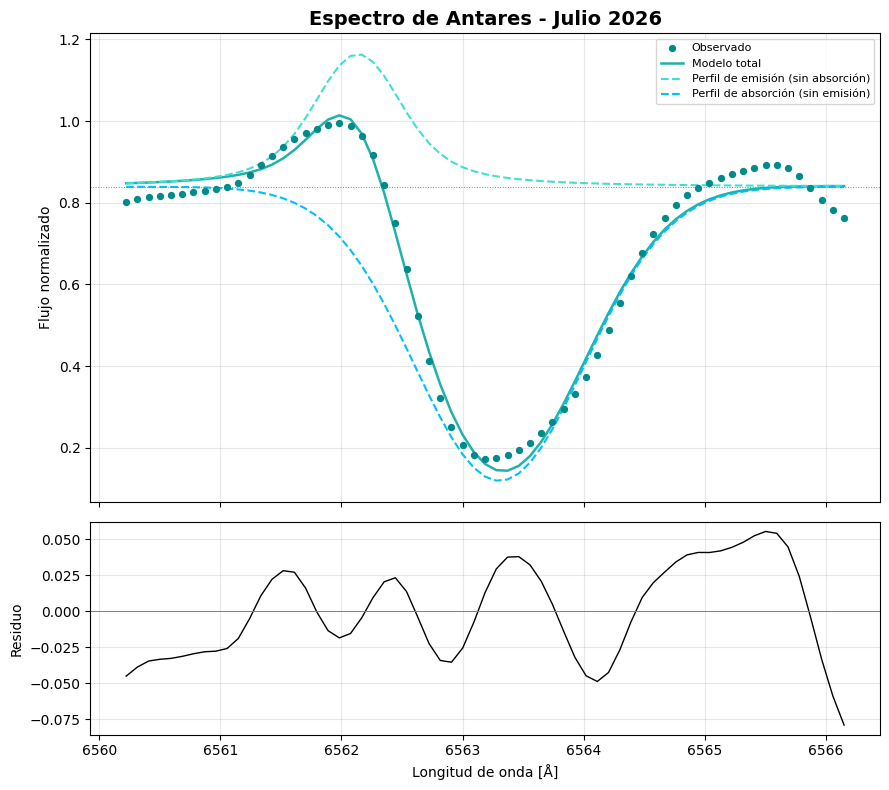

In [80]:
res = fit_y_decomposición(datos_cercanos_julio, centro_julio, "longitud_observada", "flujo_normalizado")
resumen_fisico(res["fit"])
visualizacion_decomposicion(res, titulo="Espectro de Antares - Julio 2026")


--- Resumen del ajuste ---
Emisión azul  : centro= 6562.289 Å   FWHM= 0.89 Å   altura=0.383
Absorción central: centro= 6563.465 Å   FWHM= 1.70 Å   profundidad=-0.855

Continuo local ajustado: 0.962
Chi-cuadrado reducido:   2.294e-03


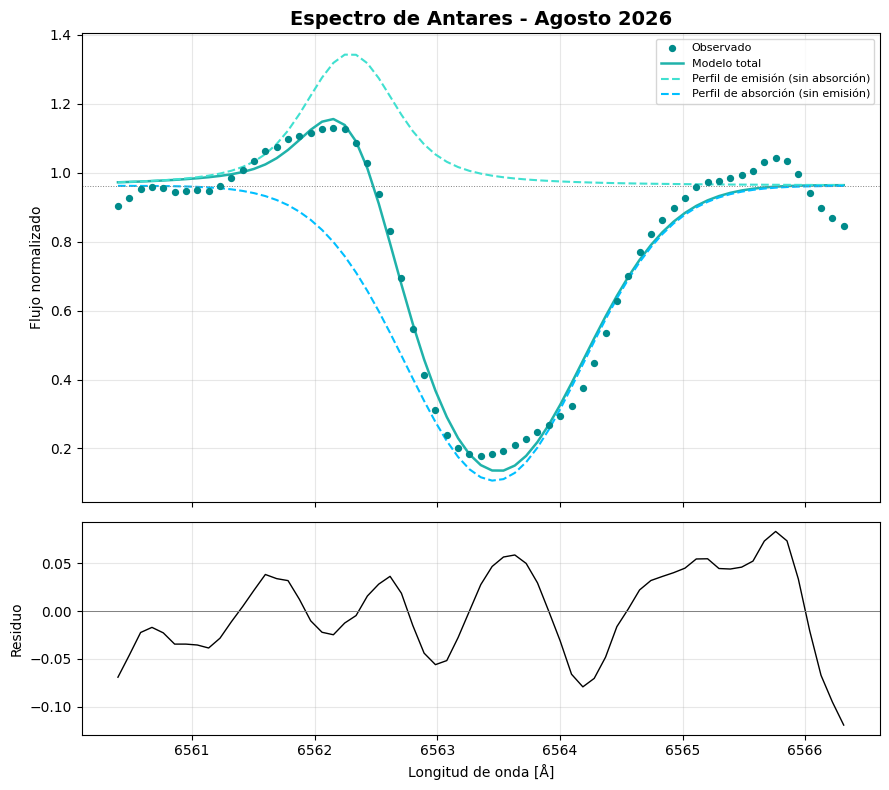

In [83]:
res_a = fit_y_decomposición(datos_cercanos_agosto, centro_agosto, "longitud_observada", "flujo_normalizado")
resumen_fisico(res_a["fit"])
visualizacion_decomposicion(res_a, titulo="Espectro de Antares - Agosto 2026")


--- Resumen del ajuste ---
Emisión azul  : centro= 6562.259 Å   FWHM= 0.92 Å   altura=0.297
Absorción central: centro= 6563.515 Å   FWHM= 1.68 Å   profundidad=-0.777

Continuo local ajustado: 0.895
Chi-cuadrado reducido:   1.629e-03


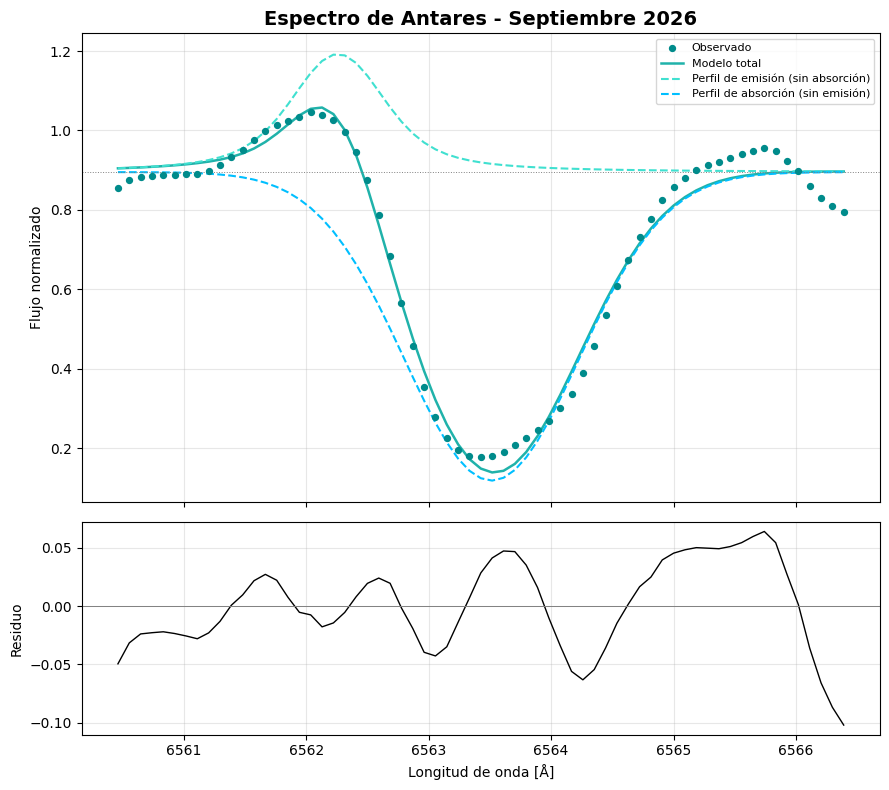

In [84]:
res_s = fit_y_decomposición(datos_cercanos_septiembre, centro_septiembre, "longitud_observada", "flujo_normalizado")
resumen_fisico(res_s["fit"])
visualizacion_decomposicion(res_s, titulo="Espectro de Antares - Septiembre 2026")

Teniendo en cuenta la línea de Cobalto

In [102]:
c_kms_s = 299792.458

def efecto_doppler(longitud_lab, velocidad_kms):
    return longitud_lab * (1 + velocidad_kms / c_kms_s)


def profundidad_interpolada(teff, t_ref=(3500, 4250), prof_ref=(0.55, 0.63)):
    return float(np.interp(teff, t_ref, prof_ref))


def amplitud_desde_profundidad(profundidad, continuo_local, sigma, gamma):
    z = 1j * gamma / (sigma * np.sqrt(2))
    pico_unitario = wofz(z).real / (sigma * np.sqrt(2 * np.pi))
    return -profundidad * continuo_local / pico_unitario

In [104]:
def construccion_del_modelo(lineas_metalicas=None):
    continuo = ConstantModel(prefix="cont_")
    em_azul = VoigtModel(prefix="em_azul_")
    valle_abs = VoigtModel(prefix="valle_abs_")
    modelo = continuo + em_azul + valle_abs

    if lineas_metalicas:
        for linea in lineas_metalicas:
            modelo += VoigtModel(prefix=f"{linea['nombre']}_")

    return modelo

def encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox,
                          lineas_metalicas, teff=3660):
    p = modelo.make_params()

    borde = np.r_[flujo[:5], flujo[-5:]]
    continuo_local = float(np.median(borde))
    p["cont_c"].set(value=continuo_local, min=0, max=2)

    izquierda = longitud_onda < centro_aprox

    # Emisión azul
    i_azul = np.argmax(flujo[izquierda])
    p["em_azul_center"].set(value=longitud_onda[izquierda][i_azul],
                             min=longitud_onda.min(), max=centro_aprox)
    p["em_azul_amplitude"].set(value=1.0, min=0)
    p["em_azul_sigma"].set(value=0.4, min=0.05, max=2)

    # Absorción central (Halpha)
    i_min = np.argmin(flujo)
    p["valle_abs_center"].set(value=longitud_onda[i_min], min=centro_aprox - 1, max=centro_aprox + 1)
    p["valle_abs_amplitude"].set(value=-(continuo_local - flujo[i_min]) * 1.5, max=0)
    p["valle_abs_sigma"].set(value=0.3, min=0.03, max=1.2)
    p["valle_abs_gamma"].set(value=0.2, min=0, max=1.2, vary=True)

    # Líneas metálicas: Doppler + profundidad física
    if lineas_metalicas:
        for linea in lineas_metalicas:
            pref = f"{linea['nombre']}_"
            c0_lab = linea["centro"]

            # Corrimiento Doppler propio de la época
            v = linea.get("velocidad", 0.0)
            c0_obs = efecto_doppler(c0_lab, v)

            # Margen de búsqueda alrededor del centro ya corregido
            
            margen_v = linea.get("incertidumbre_v", 3.0)  
            margen_aa = c0_lab * margen_v / c_kms_s
            p[f"{pref}center"].set(value=c0_obs, min=c0_obs - margen_aa, max=c0_obs + margen_aa)

            # Ancho inicial
            sigma0 = linea.get("sigma_inicial", 0.12)
            gamma0 = linea.get("gamma_inicial", 0.05)
            p[f"{pref}sigma"].set(value=sigma0, min=0.02, max=0.4)
            p[f"{pref}gamma"].set(value=gamma0, min=0, max=0.3, vary=True)

            # Profundidad física según Teff
            prof = linea.get("profundidad")  
            if prof is None:
                prof = profundidad_interpolada(
                    teff,
                    t_ref=linea.get("t_ref", (3500, 4250)),
                    prof_ref=linea.get("prof_ref", (0.55, 0.63)),
                )
            amp0 = amplitud_desde_profundidad(prof, continuo_local, sigma0, gamma0)
            p[f"{pref}amplitude"].set(value=amp0, min=amp0 * 1.8, max=0)

    return p

In [105]:
def fit_y_decomposicion(datos_cercanos, centro_aprox, longitud_observada, flujo_normalizado,
                         lineas_metalicas=None, teff=3660):
    longitud_onda = datos_cercanos[longitud_observada].to_numpy()
    flujo = datos_cercanos[flujo_normalizado].to_numpy()

    modelo = construccion_del_modelo(lineas_metalicas)
    parametros = encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox,
                                       lineas_metalicas, teff=teff)
    fit = modelo.fit(flujo, parametros, x=longitud_onda)

    comps = fit.eval_components(x=longitud_onda)
    continuo = comps["cont_"]

    perfil_emision = continuo + comps["em_azul_"]
    perfil_absorcion = continuo + comps["valle_abs_"]
    residuo = flujo - fit.best_fit

    return dict(longitud_onda = longitud_onda, flujo = flujo, fit = fit, comps = comps, perfil_emision = perfil_emision,
                perfil_absorcion = perfil_absorcion, residuo=residuo)

In [106]:
def visualizacion_con_metalica(res_metal, lineas_metalicas, mes, titulo,):
    longitud_onda, flujo, fit = res_metal["longitud_onda"], res_metal["flujo"], res_metal["fit"]
    comps = res_metal["comps"]
    continuo = comps["cont_"]

    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                              gridspec_kw={"height_ratios": [2.2, 1]})

    ax = axes[0]
    ax.scatter(longitud_onda, flujo, s=18, color="darkcyan", label="Observado", zorder=3)
    ax.plot(longitud_onda, fit.best_fit, color="lightseagreen", lw=1.8, label="Modelo total")
    ax.plot(longitud_onda, res_metal["perfil_emision"], "--", color="turquoise", lw=1.3,
            label="Perfil de emisión")
    ax.plot(longitud_onda, res_metal["perfil_absorcion"], "--", color="deepskyblue", lw=1.3,
            label=r"Perfil de absorción $H_\alpha$")

    for linea in lineas_metalicas:
        pref = f"{linea['nombre']}_"
        perfil_metal = continuo + comps[pref]
        ax.plot(longitud_onda, perfil_metal, "-.", color="purple", lw=1.3,
                label=f"Componente {linea['nombre']}")
        ax.axvline(fit.params[f"{pref}center"].value, color="orchid",
                   lw=0.7, ls=":", alpha=0.5)

    ax.axhline(continuo[0], color="gray", lw=0.7, ls=":")
    ax.set_ylabel("Flujo normalizado")
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.plot(longitud_onda, res_metal["residuo"], color="black", lw=1)
    ax2.axhline(0, color="gray", lw=0.7)
    ax2.set_xlabel("Longitud de onda [Å]")
    ax2.set_ylabel("Residuo")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"halpha_{mes.lower()}_cobalto.png", dpi=150)
    plt.show()

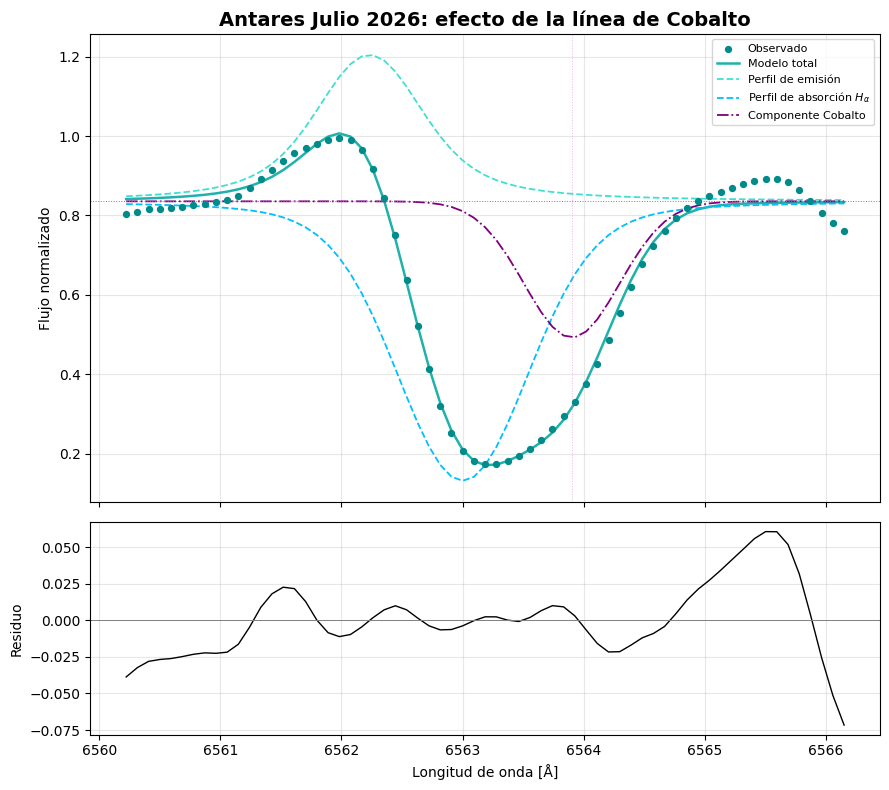

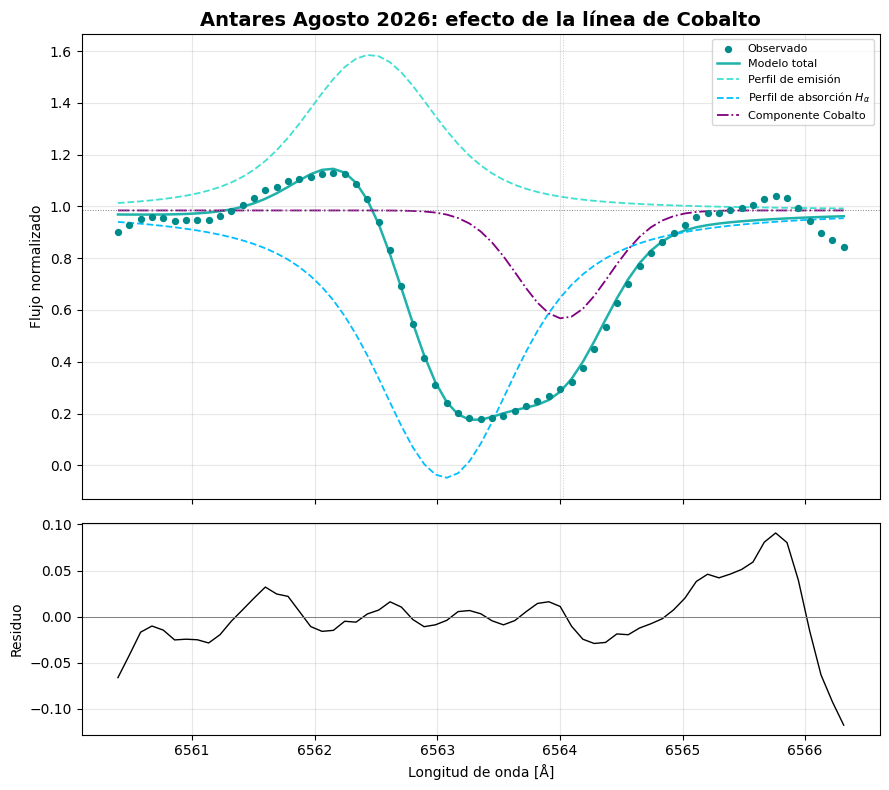

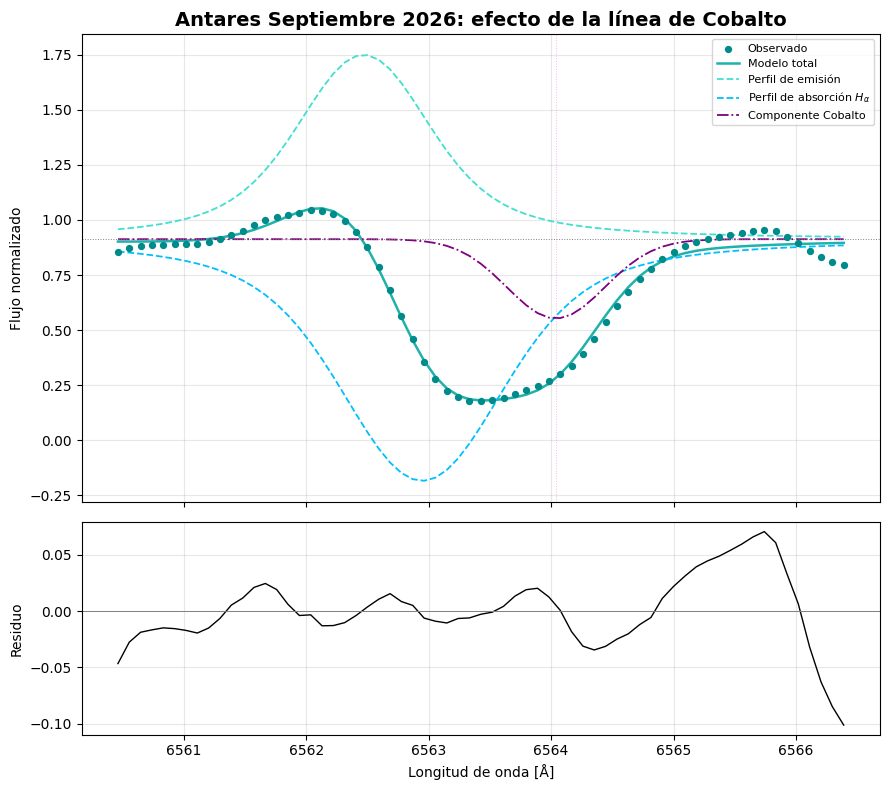

In [107]:
archivos = [
    {
        "mes": "Julio",
        "datos": datos_cercanos_julio,
        "centro_aprox": centro_julio,
        "velocidad_metalica": 22.1,   #km/s
        "incertidumbre_v":0.9,
    },
    {
        "mes": "Agosto",
        "datos": datos_cercanos_agosto,
        "centro_aprox": centro_agosto,
        "velocidad_metalica": 28.3,  # km/s 
        "incertidumbre_v": 0.4,
    },
    {
        "mes": "Septiembre",
        "datos": datos_cercanos_septiembre,
        "centro_aprox": centro_septiembre,
        "velocidad_metalica": 28.4,  # km/s
        "incertidumbre_v": 0.9,
    },
]

resultados = {}  

for archivo in archivos:
    
    mes = archivo["mes"]

    lineas_metalicas = [
        {
            "nombre": "Cobalto",
            "centro": 6563.397,
            "ion": "Co I",
            "velocidad": archivo["velocidad_metalica"],
            "incertidumbre_v": archivo["incertidumbre_v"],
            "prof_ref": (0.55, 0.63),
            "t_ref": (3500, 4250),
        }
    ]

    res = fit_y_decomposicion(archivo["datos"], archivo["centro_aprox"],
                               "longitud_observada", "flujo_normalizado",
                               lineas_metalicas=lineas_metalicas, teff=3660)

    resultados[mes] = res

    visualizacion_con_metalica(res, lineas_metalicas, mes,
                                titulo=f"Antares {mes} 2026: efecto de la línea de Cobalto")